In [2]:

from tifffile import imread, imwrite
import numpy as np
from shapely.geometry import Polygon, Point, MultiPoint, MultiPolygon, box
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import scanpy as sc
import skimage.filters
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Wedge, Patch
from shapely.affinity import translate
import pandas as pd        
from matplotlib.patches import Circle, Wedge
import seaborn as sns

In [3]:
col_img = imread("/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/data/human_colon/Visium_HD_Human_Colon_Cancer_tissue_image.btf")
star_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_colon/human_colon_run/stardist_nuclei.gpkg')
star_vor_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_colon/human_colon_run/stardist_voronoi_cyto.gpkg')
b2c_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_colon/human_colon_run/bin2cell_cyto.gpkg')
adata = sc.read_h5ad('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_colon/human_colon_run/adata_processed.h5ad')

/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/envs/jl_snakemake_env2.0/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
tumor_genes = ['CEACAM6', 'NKD1', 'KRT23']
goblet_genes = ['FCGBP', 'MUC2', 'CLCA1']
fibroblast_genes = ['COL1A1', 'MMP2']
macrophage_genes = ['C1QC', 'LYZ', 'CD68']
housekeeping_genes = ['ACTB', 'B2M', 'GUSB', 'HPRT1', 'IPO8', 'PGK1', 'PPIA', 'SDHA', 'TBP', 'UBC', 'YWHAZ'] # https://pubmed.ncbi.nlm.nih.gov/24859296/#:~:text=The%20RPS23%2C%20PPIA%2C%20and%20RPLP0,or%20B2M%20is%20not%20recommended.
# Expression stability of common housekeeping genes is differently affected by bowel inflammation and cancer: implications for finding suitable normalizers for inflammatory bowel disease studies
#  ['GAPDH', 'MRPL19', 'RPLP0', 'RPS23'] Were not in any of the adata...

In [5]:
adata.var_names_make_unique()
adata.obs['goblet_expression'] = adata[:, goblet_genes].X.sum(axis=1)
adata.obs['FCGBP'] = adata[:, 'FCGBP'].X.toarray().flatten()
adata.obs['MUC2'] = adata[:, 'MUC2'].X.toarray().flatten()
adata.obs['CLCA1'] = adata[:, 'CLCA1'].X.toarray().flatten()
adata.obs['housekeeping_expression']= adata[:, housekeeping_genes].X.sum(axis=1)


# extract coordinates (assuming they’re stored in adata.obs)
df_pos = adata.obs[['pxl_col_in_fullres', 'pxl_row_in_fullres', 'goblet_expression', 'FCGBP', 'MUC2', 'CLCA1', 'housekeeping_expression' ]].copy()

# create geometry
geometry = [Point(xy) for xy in zip(df_pos['pxl_col_in_fullres'], df_pos['pxl_row_in_fullres'])]

# make GeoDataFrame
gdf = gpd.GeoDataFrame(df_pos, geometry=geometry)


In [6]:
microns_per_pixel = 0.2738242950835738

region_x = [55400, 55650]
region_y= [11200, 11400]

In [7]:
# crop image 
cropped_img = col_img[region_y[0]:region_y[1], region_x[0]:region_x[1], :]

# filter gdfs to region
region_box = box(region_x[0], region_y[0], region_x[1], region_y[1])
gdf_cropped = gdf[gdf.intersects(region_box)]
star_gdf = star_gdf[star_gdf.intersects(region_box)]
star_vor_gdf = star_vor_gdf[star_vor_gdf.intersects(region_box)]
b2c_gdf = b2c_gdf[b2c_gdf.intersects(region_box)]



# shift all geometries by negative crop offsets
gdf_cropped["geometry"] = gdf_cropped.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
trans_star_gdf = star_gdf.copy()
trans_star_vor_gdf = star_vor_gdf.copy()
trans_b2c_gdf = b2c_gdf.copy()
trans_star_gdf["geometry"] = trans_star_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
trans_star_vor_gdf["geometry"] = trans_star_vor_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
trans_b2c_gdf["geometry"] = trans_b2c_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])

/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/envs/jl_snakemake_env2.0/lib/python3.10/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


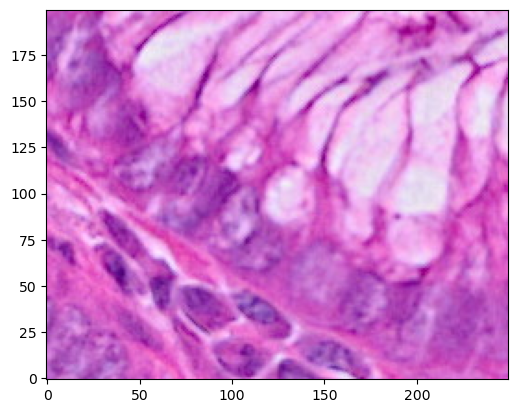

In [8]:
plt.imshow(cropped_img, origin='lower')


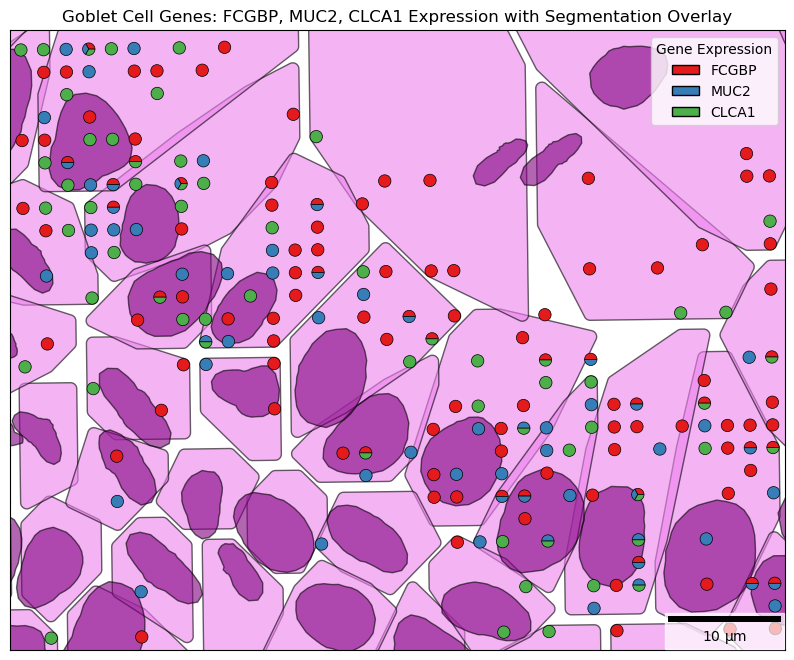

In [9]:
goblet_gdf = gdf_cropped[gdf_cropped['goblet_expression'] > 0]
# Gene colors
gene_colors = {'FCGBP': '#e41a1c', 'MUC2': '#377eb8', 'CLCA1': '#4daf4a'}

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(10,10))

# Optional: background polygons
trans_star_vor_gdf.plot(ax=ax, edgecolor='black', facecolor='violet', linewidth=1, alpha=0.6)
trans_star_gdf.plot(ax=ax, edgecolor='black', facecolor='purple', linewidth=1, alpha=0.6)

# Overlay image
#plt.imshow(cropped_img, alpha=1)

# Plot points
for idx, row in goblet_gdf.iterrows():
    expressed_genes = [gene for gene in gene_colors if row[gene] > 0]
    x, y = row.geometry.x, row.geometry.y
    
    if len(expressed_genes) == 0:
        ax.plot(x, y, 'o', color='lightgrey', markersize=5)
    elif len(expressed_genes) == 1:
        # Circle for a single gene
        circle = Circle((x, y), radius=2, facecolor=gene_colors[expressed_genes[0]],
                edgecolor='black', linewidth=0.5)
        ax.add_patch(circle)
    elif len(expressed_genes) == 2:
        # Create pie/wedge for 2 genes (split 180° each)
        for i, gene in enumerate(expressed_genes):
            wedge = Wedge(center=(x, y), r=2, theta1=i*180, theta2=(i+1)*180,
                          facecolor=gene_colors[gene], edgecolor='black',linewidth=0.5)
            ax.add_patch(wedge)
    else:
        # 3 genes expressed: 3-way pie (120° each)
        for i, gene in enumerate(expressed_genes):
            wedge = Wedge(center=(x, y), r=2, theta1=i*120, theta2=(i+1)*120,
                          facecolor=gene_colors[gene], edgecolor='black',linewidth=0.5)
            ax.add_patch(wedge)

# Scale bar
scalebar = ScaleBar(
    dx=microns_per_pixel,
    units='µm',
    location='lower right',
    scale_loc='bottom',
    color='black',
    box_alpha=0.7
)
ax.add_artist(scalebar)

legend_elements = [
    Patch(facecolor=gene_colors['FCGBP'], edgecolor='k', label='FCGBP'),
    Patch(facecolor=gene_colors['MUC2'], edgecolor='k', label='MUC2'),
    Patch(facecolor=gene_colors['CLCA1'], edgecolor='k', label='CLCA1')]

# Instead of hatch, you could create example pie patches if you want
ax.legend(handles=legend_elements, loc='upper right', title='Gene Expression')
ax.set_xlim(0, 250)
ax.set_ylim(0, 200)
ax.set_xticks([])
ax.set_yticks([])
plt.title('Goblet Cell Genes: FCGBP, MUC2, CLCA1 Expression with Segmentation Overlay')
plt.savefig('cell_type_fig/goblet_genes_visual_overlay.pdf', dpi=300, bbox_inches='tight')
plt.show()



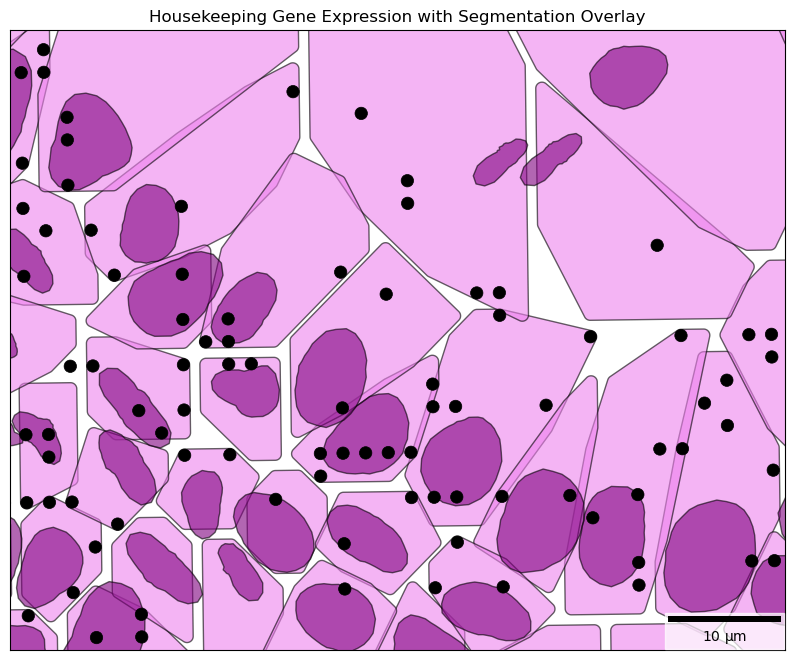

In [10]:
housekeeping_gdf = gdf_cropped[gdf_cropped['housekeeping_expression'] > 0]
#plot gdf
fig, ax = plt.subplots(figsize=(10,10))

trans_star_vor_gdf.plot(ax=ax, edgecolor='black', facecolor='violet', linewidth=1, alpha=0.6)
trans_star_gdf.plot(ax=ax, edgecolor='black', facecolor='purple', linewidth=1, alpha=0.6)

for idx, row in housekeeping_gdf.iterrows():
    x, y = row.geometry.x, row.geometry.y
    # Circle for a single gene
    circle = Circle((x, y), radius=2, facecolor='black',
                edgecolor='black', linewidth=0.5)
    ax.add_patch(circle)

#plt.imshow(cropped_img, origin = 'lower', alpha=0.5)

# Add scale bar
scalebar = ScaleBar(
    dx=microns_per_pixel,        # microns per pixel
    units='µm',                  # micron units
    location='lower right',      # where to place it
    scale_loc='bottom',          # label below bar
    color='black',               # scale bar color
    box_alpha=0.7                # background transparency
)

plt.gca().add_artist(scalebar)
plt.title('Housekeeping Gene Expression with Segmentation Overlay')
ax.set_xlim(0, 250)
ax.set_ylim(0, 200)
ax.set_xticks([])
ax.set_yticks([])
plt.savefig('cell_type_fig/housekeeping_genes_visual_overlay.pdf', dpi=300, bbox_inches='tight')
plt.show()

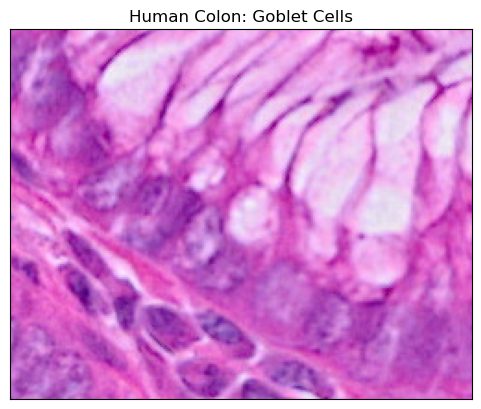

In [11]:
plt.imshow(cropped_img, origin='lower', alpha=1)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.title('Human Colon: Goblet Cells')
plt.savefig('cell_type_fig/goblet_roi_tissue.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# join gdf_cropped with star_vor_gdf and star_gdf & compare how much goblet_expression is in each 

def proportion_expression_inside(gdf_points, gdf_polygons, poly_name, column):
    """
    gdf_points: GeoDataFrame with 'column' and point geometries
    gdf_polygons: GeoDataFrame with polygon geometries
    poly_name: string label for this polygon type
    """

    # Spatial join: assign points to polygons
    joined = gpd.sjoin(gdf_points, gdf_polygons, how='left', predicate='within')
    print(joined.index.duplicated().sum())
    # drop duplicates if any
    joined = joined[~joined.index.duplicated(keep='first')]

    
    # Points inside polygon: those with index_right not null
    inside_expr = joined.loc[joined['index_right0'].notna(), column].sum()
    total_expr = gdf_points[column].sum()
    outside_expr = total_expr - inside_expr

    # Return as DataFrame for plotting
    df = pd.DataFrame({
        'Polygon_Type': [poly_name, poly_name],
        'Location': ['Inside', 'Outside'],
        f'{column}': [inside_expr, outside_expr],
        'Proportion': [inside_expr / total_expr, outside_expr / total_expr]
    })
    return df

In [13]:


gob_star_vor_expr_df = proportion_expression_inside(gdf_cropped, trans_star_vor_gdf, 'StarDist Voronoi', 'goblet_expression')
gob_star_nuclei_expr_df = proportion_expression_inside(gdf_cropped, trans_star_gdf, 'StarDist Nuclei', 'goblet_expression')
gob_b2c_expr_df = proportion_expression_inside(gdf_cropped,trans_b2c_gdf ,'Bin2cell', 'goblet_expression')
combined_gob_expr_df = pd.concat([gob_star_vor_expr_df, gob_star_nuclei_expr_df,gob_b2c_expr_df], ignore_index=True)


house_star_vor_expr_df = proportion_expression_inside(housekeeping_gdf, trans_star_vor_gdf, 'StarDist Voronoi', 'housekeeping_expression')
house_star_nuclei_expr_df = proportion_expression_inside(housekeeping_gdf, trans_star_gdf, 'StarDist Nuclei', 'housekeeping_expression')
house_b2c_expr_df = proportion_expression_inside(gdf_cropped,trans_b2c_gdf ,'Bin2cell', 'housekeeping_expression')
combined_house_expr_df = pd.concat([house_star_vor_expr_df, house_star_nuclei_expr_df,house_b2c_expr_df], ignore_index=True)

16
0
0
2
0
0


In [14]:
test = proportion_expression_inside(gdf, star_gdf, 'StarDist Voronoi', 'housekeeping_expression')
test


0


,Polygon_Type,Location,housekeeping_expression,Proportion
0,StarDist Voronoi,Inside,52.0,0.000033
1,StarDist Voronoi,Outside,1570525.0,0.999967


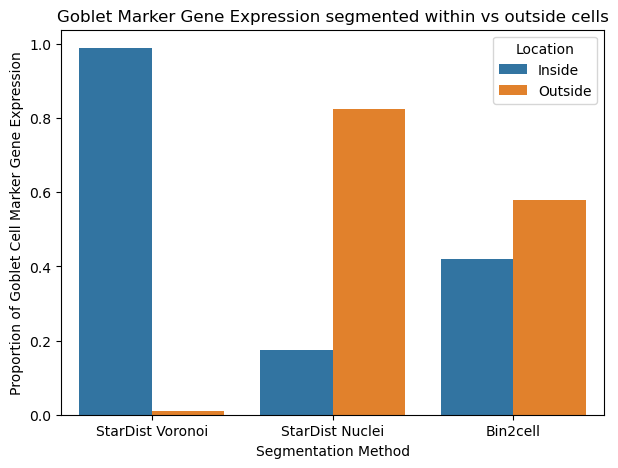

In [15]:
fig, ax = plt.subplots(figsize=(7,5))

sns.barplot(
    x='Polygon_Type',
    y='Proportion',
    hue='Location',
    data=combined_gob_expr_df,
    palette=['#1f77b4', '#ff7f0e']
)
ax.set_xlabel('Segmentation Method')
ax.set_ylabel('Proportion of Goblet Cell Marker Gene Expression')
ax.set_title('Goblet Marker Gene Expression segmented within vs outside cells')
plt.legend(title='Location')
plt.savefig('cell_type_fig/goblet_gene_expression_proportion_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()


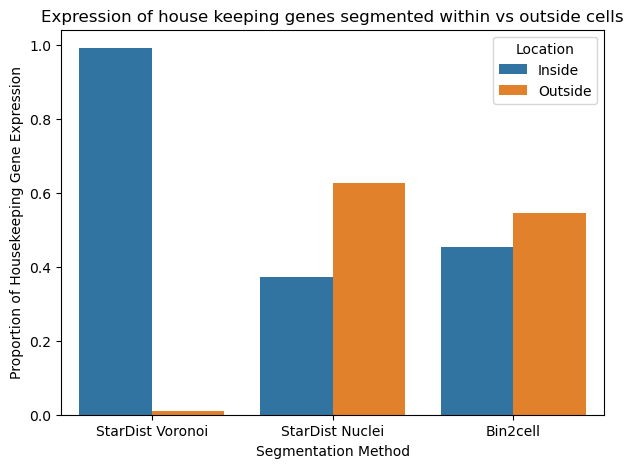

In [16]:

fig, ax = plt.subplots(figsize=(7,5))

sns.barplot(
    x='Polygon_Type',
    y='Proportion',
    hue='Location',
    data=combined_house_expr_df,
    palette=['#1f77b4', '#ff7f0e']
)
ax.set_xlabel('Segmentation Method')
ax.set_ylabel('Proportion of Housekeeping Gene Expression')
ax.set_title('Expression of house keeping genes segmented within vs outside cells')
plt.legend(title='Location')
plt.savefig('cell_type_fig/housekeeping_gene_expression_proportion_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
combined_house_expr_df.rename(columns={'Proportion': 'Housekeeping_Proportion'}, inplace=True)
combined_gob_expr_df.rename(columns={'Proportion': 'Goblet_Proportion'}, inplace=True)
final_combined_df = pd.merge(
    combined_gob_expr_df[['Polygon_Type', 'Location', 'Goblet_Proportion']],
    combined_house_expr_df[['Polygon_Type', 'Location', 'Housekeeping_Proportion']],
    on=['Polygon_Type', 'Location']
)

In [18]:
final_combined_inside_df = final_combined_df[final_combined_df['Location'] == 'Inside']

In [19]:
final_combined_inside_df

,Polygon_Type,Location,Goblet_Proportion,Housekeeping_Proportion
0,StarDist Voronoi,Inside,0.988848,0.990909
2,StarDist Nuclei,Inside,0.174721,0.372727
4,Bin2cell,Inside,0.420074,0.454545


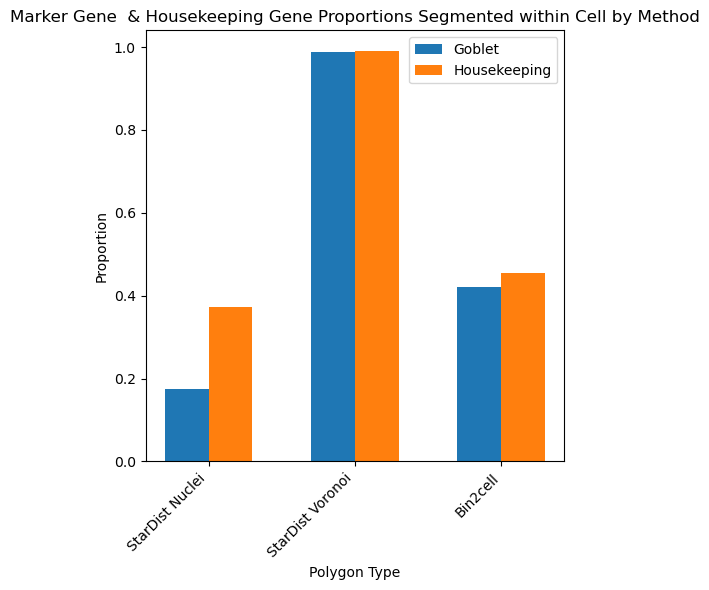

In [20]:
polygon_types = final_combined_inside_df["Polygon_Type"].unique()
x = np.arange(len(polygon_types))
bar_width = 0.3
plot_order = ['StarDist Nuclei', 'StarDist Voronoi', 'Bin2cell']

# Aggregate (mean per polygon type)
grouped = (
    final_combined_inside_df.groupby("Polygon_Type")[["Goblet_Proportion", "Housekeeping_Proportion"]]
    .mean()
    .reindex(plot_order)   

)

fig, ax = plt.subplots(figsize=(5, 6))

ax.bar(
    x - bar_width / 2,
    grouped["Goblet_Proportion"],
    width=bar_width,
    label="Goblet",
)

ax.bar(
    x + bar_width / 2,
    grouped["Housekeeping_Proportion"],
    width=bar_width,
    label="Housekeeping",
)

ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=45, ha="right")

ax.set_ylabel("Proportion")
ax.set_xlabel("Polygon Type")
ax.set_title("Marker Gene  & Housekeeping Gene Proportions Segmented within Cell by Method")
ax.legend()
plt.savefig('cell_type_fig/HC_combined_gene_expression_proportion_barplot.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()



# Mouse Brain 

In [2]:
import celltypist
from celltypist import models
models.download_models(force_update = True)
model_name = 'Developing_Mouse_Hippocampus.pkl'
model = models.Model.load(model = model_name)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /uufs/chpc.utah.edu/common/home/u1531817/.celltypist/data/models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: 

In [3]:
# load data
brain_img = imread("/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/data/mouse_brain/Visium_HD_Mouse_Brain_tissue_image.tif")
bin2cell_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/mouse_brain/mouse_brain_run/bin2cell_cyto.gpkg')
star_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/mouse_brain/mouse_brain_run/stardist_nuclei.gpkg')
star_vor_gdf = gpd.read_file('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/mouse_brain/mouse_brain_run/stardist_voronoi_cyto.gpkg')
adata = sc.read_h5ad('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/mouse_brain/mouse_brain_run/adata_processed.h5ad')

In [4]:
# filter ann
adata.var_names_make_unique()
adata_filtered = adata.copy()

In [5]:
# extract top genes
top_genes = 3
top_granule_genes = model.extract_top_markers("GranuleNB", top_genes)
top_granule_genes = top_granule_genes.tolist()




In [6]:
top_granule_genes

['Neurod1', 'Prox1', 'Igfbpl1']

In [7]:
adata_filtered

AnnData object with n_obs × n_vars = 6296688 × 19059
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'index'
    var: 'gene_ids', 'feature_types', 'genome'

In [8]:
adata_filtered.var_names_make_unique()

adata_filtered.obs['granule_expression'] = adata_filtered[:, top_granule_genes].X.sum(axis=1)
adata_filtered.obs['Neurod1'] = adata_filtered[:, 'Neurod1'].X.toarray().flatten()
adata_filtered.obs['Prox1'] = adata_filtered[:, 'Prox1'].X.toarray().flatten()
adata_filtered.obs['Igfbpl1'] = adata_filtered[:, 'Igfbpl1'].X.toarray().flatten()

# extract coordinates 
df_pos = adata_filtered.obs[['pxl_col_in_fullres', 'pxl_row_in_fullres', 'granule_expression', 'Neurod1', 'Prox1','Igfbpl1']].copy()

# create geometry
geometry = [Point(xy) for xy in zip(df_pos['pxl_col_in_fullres'], df_pos['pxl_row_in_fullres'])]

# make GeoDataFrame
gdf = gpd.GeoDataFrame(df_pos, geometry=geometry)

In [9]:
region_x=[15000+400, 15000+575] 
region_y=[7500+450, 7500+600]

# plot gdf and image
cropped_img = brain_img[region_y[0]:region_y[1], region_x[0]:region_x[1], :]
# filter gdf to region
region_box = box(region_x[0], region_y[0], region_x[1], region_y[1])
gdf_cropped = gdf[gdf.intersects(region_box)]
from shapely.affinity import translate
# shift all geometries by negative crop offsets
# filter gdf to region
region_box = box(region_x[0], region_y[0], region_x[1], region_y[1])
gdf_cropped = gdf[gdf.intersects(region_box)]

from shapely.affinity import translate

# shift all geometries by negative crop offsets
gdf_cropped["geometry"] = gdf_cropped.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
trans_star_gdf = star_gdf.copy()
trans_star_vor_gdf = star_vor_gdf.copy()
trans_bin2cell_gdf = bin2cell_gdf.copy()
trans_star_gdf["geometry"] = trans_star_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
trans_star_vor_gdf["geometry"] = trans_star_vor_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
trans_bin2cell_gdf["geometry"] = trans_bin2cell_gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])



/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/envs/jl_snakemake_env2.0/lib/python3.10/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
region_adata = adata.obs.index.isin(gdf_cropped.index.tolist())
region_adata = adata[region_adata, :].copy()
# find gene expressed in the most rows
expr_bool = region_adata.X > 0

# If region_adata.X is sparse (common), convert to CSR first
if hasattr(expr_bool, "toarray"):  # sparse matrix
    expr_bool = expr_bool.toarray()

# Count number of cells per gene
gene_counts = expr_bool.sum(axis=0)  # sum over cells (rows)

# Put into a pandas Series with gene names
gene_counts = pd.Series(gene_counts, index=region_adata.var_names)

# Find the gene expressed in the most cells
most_cells_gene = gene_counts.idxmax()
most_cells_count = gene_counts.max()

print(f"Gene expressed in most cells: {most_cells_gene} ({most_cells_count} cells)")

Gene expressed in most cells: Ncdn (159 cells)


In [11]:

gdf_cropped = gdf_cropped[gdf_cropped['granule_expression'] > 0]


In [13]:
microns_per_pixel=0.2738242950835738

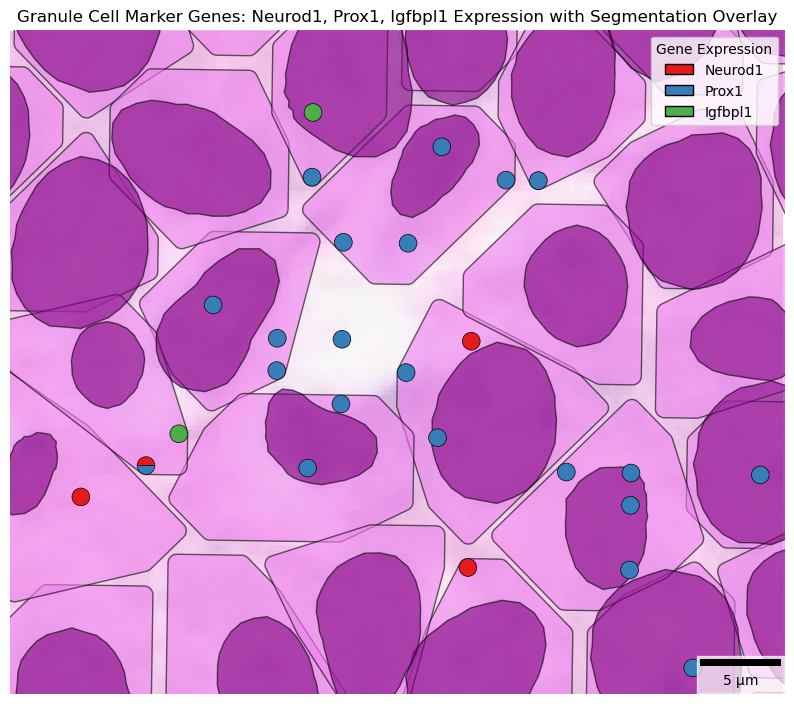

In [18]:
# Gene colors
gene_colors = {'Neurod1': '#e41a1c', 'Prox1': '#377eb8', 'Igfbpl1': '#4daf4a'}

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(10,10))

# Optional: background polygons
trans_star_vor_gdf.plot(ax=ax, edgecolor='black', facecolor='violet', linewidth=1, alpha=0.6)
trans_star_gdf.plot(ax=ax, edgecolor='black', facecolor='purple', linewidth=1, alpha=0.6)

# Overlay image
plt.imshow(cropped_img, alpha=0.5)

# Plot points
for idx, row in gdf_cropped.iterrows():
    expressed_genes = [gene for gene in gene_colors if row[gene] > 0]
    x, y = row.geometry.x, row.geometry.y
    
    if len(expressed_genes) == 0:
        ax.plot(x, y, 'o', color='lightgrey', markersize=5)
    elif len(expressed_genes) == 1:
        # Circle for a single gene
        circle = Circle((x, y), radius=2, facecolor=gene_colors[expressed_genes[0]],
                edgecolor='black', linewidth=0.5)
        ax.add_patch(circle)    
    elif len(expressed_genes) == 2:
        # Create pie/wedge for 2 genes (split 180° each)
        for i, gene in enumerate(expressed_genes):
            wedge = Wedge(center=(x, y), r=2, theta1=i*180, theta2=(i+1)*180,
                          facecolor=gene_colors[gene], edgecolor='black',linewidth=0.5)
            ax.add_patch(wedge)
    else:
        # 3 genes expressed: 3-way pie (120° each)
        for i, gene in enumerate(expressed_genes):
            wedge = Wedge(center=(x, y), r=2, theta1=i*120, theta2=(i+1)*120,
                          facecolor=gene_colors[gene], edgecolor='black',linewidth=0.5)
            ax.add_patch(wedge)

# Scale bar
scalebar = ScaleBar(
    dx=microns_per_pixel,
    units='µm',
    location='lower right',
    scale_loc='bottom',
    color='black',
    box_alpha=0.7
)
ax.add_artist(scalebar)

legend_elements = [
    Patch(facecolor=gene_colors['Neurod1'], edgecolor='k', label='Neurod1'),
    Patch(facecolor=gene_colors['Prox1'], edgecolor='k', label='Prox1'),
    Patch(facecolor=gene_colors['Igfbpl1'], edgecolor='k', label='Igfbpl1')]

# Instead of hatch, you could create example pie patches if you want
ax.legend(handles=legend_elements, loc='upper right', title='Gene Expression')
ax.set_xlim(0, 175)
ax.set_ylim(0, 150)
plt.title('Granule Cell Marker Genes: Neurod1, Prox1, Igfbpl1 Expression with Segmentation Overlay')
ax.axis('off')
plt.savefig('cell_type_fig/granule_genes_visual_overlay.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
region_box = box(14000, 6500, 16000, 8500)
gdf_full_section = gdf[gdf.intersects(region_box)]

In [20]:
# Compute proportions for all three polygon sets
df_star = proportion_expression_inside(gdf_full_section, star_gdf, 'Star', 'granule_expression' )
df_b2c = proportion_expression_inside(gdf_full_section, bin2cell_gdf, 'B2C', 'granule_expression')
df_star_vor = proportion_expression_inside(gdf_full_section, star_vor_gdf, 'Star_Vor', 'granule_expression')

# Combine
df_all = pd.concat([df_star, df_b2c, df_star_vor], ignore_index=True)


0
5
1360


In [24]:
df_prop_in = df_all[df_all['Location'] == 'Inside']

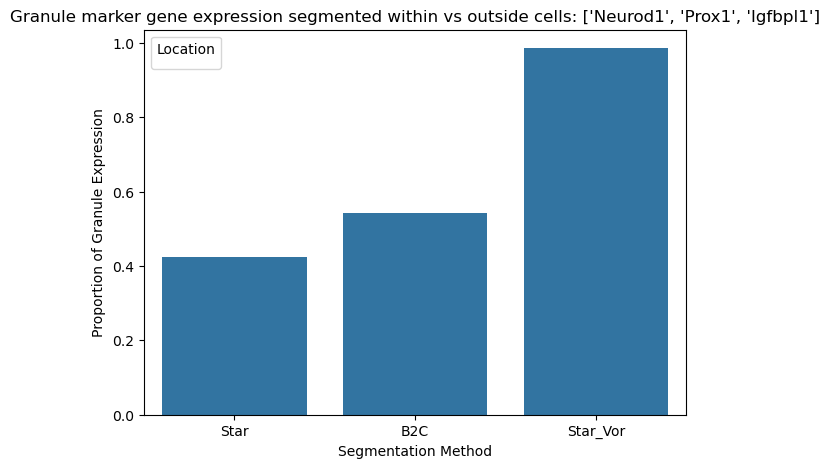

In [29]:

fig, ax = plt.subplots(figsize=(7,5))

sns.barplot(
    x='Polygon_Type',
    y='Proportion',
    data=df_prop_in,
)
ax.set_xlabel('Segmentation Method')
ax.set_ylabel('Proportion of Granule Expression')
ax.set_title(f'Granule marker gene expression segmented within vs outside cells: {top_granule_genes}')
plt.legend(title='Location')
plt.savefig('cell_type_fig/granule_gene_expression_proportion_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()
